# Plotting rate RNN energy landscape

Plotting on a single landscape

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
import pickle as pk
from sklearn.decomposition import PCA
import torch

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
# import model
from model import generate_input_stim_xor, eval_tf

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import vis_utils as vu
import trajectory_utils as tu
import importlib

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/trajectory/fixed_pt/')
import load_RNN_model as lrm
from run_RNN_search import get_period_pca

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/fixed-point-finder')
from FixedPointFinderTorch import FixedPointFinderTorch as FixedPointFinder
from plot_utils import plot_fps # in fixedpointfinder folder

/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-03-02 17:27:54.385133: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-02 17:27:54.392735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-02 17:27:54.400978: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register facto

Instructions for updating:
non-resource variables are not supported in the long term


## Good model

In [13]:
models_type = 'good_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
good_model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [3]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

Loading synX


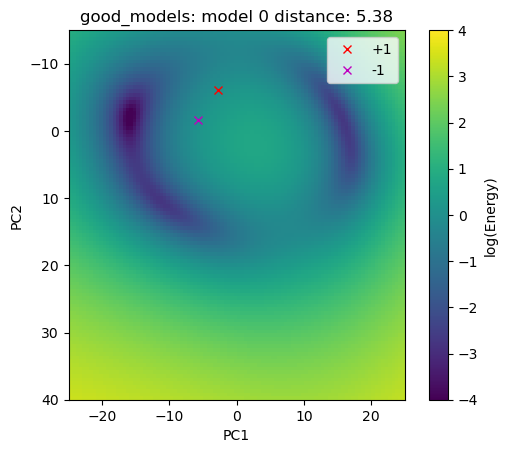

Loading synX


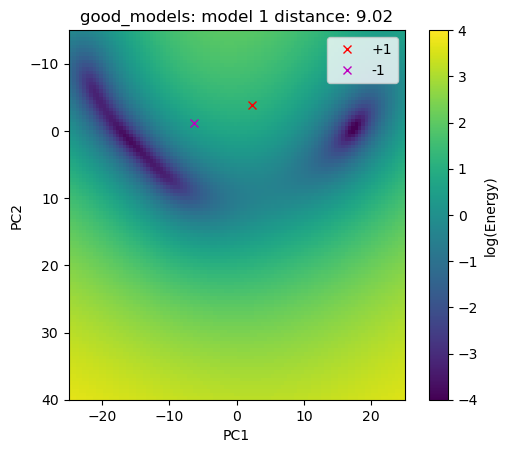

Loading synX


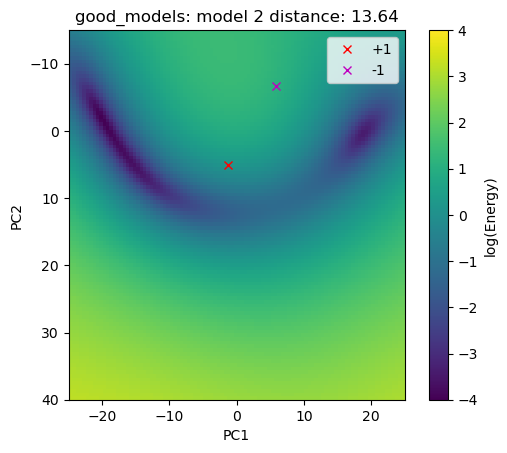

In [14]:
# delay = 150
importlib.reload(tu)
for i_model in range(len(good_model_list)):
    model_path = os.path.join(models_dir, good_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    # print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
    # perf = tu.get_perf(model_path = model_path, 
    #                    settings=settings, n_trials=100, plot=0)

    tu.plot_energy_landscape_over_null(good_model_list[i_model], settings, 
                             title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    
    if i_model == 2:
        break

## Bad model

In [7]:
models_type = 'bad_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
bad_model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [8]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

Loading synX


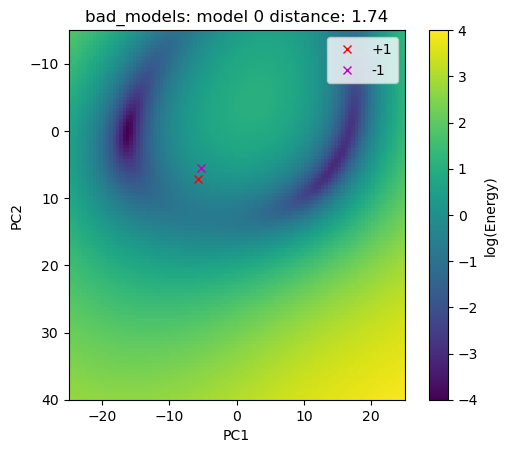

Loading synX


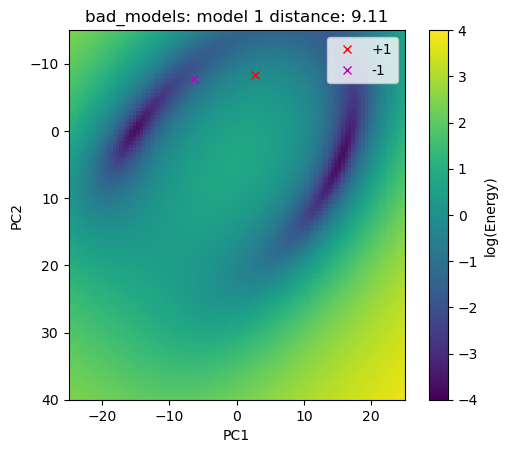

Loading synX


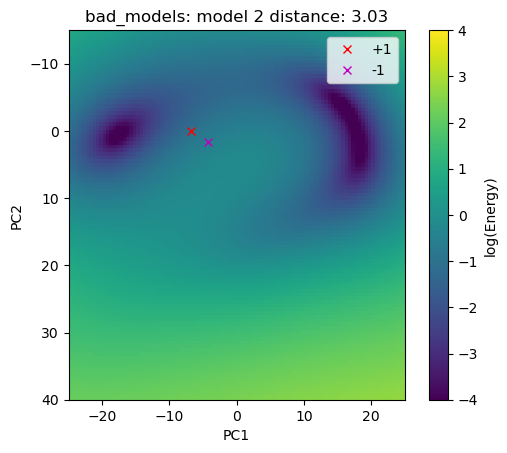

In [11]:
# delay = 150
importlib.reload(tu)
for i_model in range(len(bad_model_list)):
    model_path = os.path.join(models_dir, bad_model_list[i_model])
    model = scipy.io.loadmat(model_path)
    # print(f'spiking model perf: {np.nanmean(model["stable_perfs"])}')
    # perf = tu.get_perf(model_path = model_path, 
    #                    settings=settings, n_trials=100, plot=1)

    tu.plot_energy_landscape_over_null(bad_model_list[i_model], settings, 
                             title=f'{models_type}: model {i_model}')#, perf={perf:.2f}')
    
    if i_model == 2:
        break